<a href="https://colab.research.google.com/github/ravitbarlev/DS23_Module3_Assignment2_Unsupervised_Starter.ipynb/blob/main/RAVIT_DS23_Session16_Demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DS23 · Session 16 Demo
## Supervised Learning Foundations: k-NN, Linear & Logistic Regression, Regularization

**BIU DS23 by Shlomit Levavi**

This live demo runs on the real **Olist Brazilian E-Commerce** dataset. Throughout the supervised-learning block we follow one consistent thread:

- **Regression** · predict the *shipping cost* (`freight`) of an order from its package size.
- **Classification** · predict whether an order will get a *negative review* (score 1-2) from its delivery experience.

Every number you see below is computed from the actual data, not invented.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount ('/content/drive')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             r2_score, mean_absolute_error, mean_squared_error)

sns.set_theme(style="whitegrid")
np.random.seed(42)

# >>> Set this to the folder holding the Olist CSV files <<<
#OLIST_PATH = "olist"   # folder with the Olist CSV files
OLIST_PATH = "/content/drive/MyDrive/RAVIT BIU DS23/Class3_4/Data/Brazilian E-Commerce Public Dataset by Olist (Unzipped Files)"

print("Looking for Olist CSVs in:", os.path.abspath(OLIST_PATH))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Looking for Olist CSVs in: /content/drive/MyDrive/RAVIT BIU DS23/Class3_4/Data/Brazilian E-Commerce Public Dataset by Olist (Unzipped Files)


### Build the analytical base table

We merge orders, items, products and reviews into one order-level table. This same table powers every model in the block, so the story stays consistent.

In [ ]:
def load_olist(path=OLIST_PATH):
    orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"),
                         parse_dates=["order_purchase_timestamp", "order_approved_at",
                                      "order_delivered_customer_date", "order_estimated_delivery_date"])
    items    = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
    reviews  = pd.read_csv(os.path.join(path, "olist_order_reviews_dataset.csv"))
    products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))
    return orders, items, reviews, products

def build_base_table(orders, items, reviews, products):
    # 1) delivered orders with valid timestamps -> delivery features
    o = orders[orders["order_status"] == "delivered"].copy()
    o = o.dropna(subset=["order_delivered_customer_date", "order_purchase_timestamp",
                         "order_estimated_delivery_date"])
    o["delivery_days"]     = (o["order_delivered_customer_date"] - o["order_purchase_timestamp"]).dt.total_seconds() / 86400
    o["delay_vs_estimate"] = (o["order_delivered_customer_date"] - o["order_estimated_delivery_date"]).dt.total_seconds() / 86400
    o = o[(o["delivery_days"] > 0) & (o["delivery_days"] < 60)]

    # 2) product size, then aggregate items to order level
    prod = products.copy()
    prod["volume_cm3"] = prod["product_length_cm"] * prod["product_height_cm"] * prod["product_width_cm"]
    it = items.merge(prod[["product_id", "product_weight_g", "volume_cm3"]], on="product_id", how="left")
    agg = it.groupby("order_id").agg(
        freight_total=("freight_value", "sum"),
        price_total=("price", "sum"),
        weight_total=("product_weight_g", "sum"),
        volume_total=("volume_cm3", "sum"),
        n_items=("order_item_id", "count")).reset_index()

    # 3) review score (mean per order) -> negative label
    rv = reviews.groupby("order_id")["review_score"].mean().reset_index()

    df = o.merge(agg, on="order_id", how="inner").merge(rv, on="order_id", how="inner")
    df["is_negative"] = (df["review_score"] <= 2).astype(int)
    df = df.dropna(subset=["freight_total", "price_total", "weight_total", "volume_total",
                           "delivery_days", "delay_vs_estimate"])
    df = df[(df["freight_total"] > 0) & (df["freight_total"] < 400) &
            (df["weight_total"] > 0) & (df["weight_total"] < 50000)]
    return df.reset_index(drop=True)

orders, items, reviews, products = load_olist()
df = build_base_table(orders, items, reviews, products)

print("Base table shape:", df.shape)
print("Negative-review rate: {:.1%}".format(df["is_negative"].mean()))
df[["delivery_days", "delay_vs_estimate", "freight_total", "weight_total", "is_negative"]].head()

Base table shape: (95091, 17)
Negative-review rate: 12.6%


,delivery_days,delay_vs_estimate,freight_total,weight_total,is_negative
0,8.436574,-7.107488,8.72,500.0,0
1,13.782037,-5.355729,22.76,400.0,0
2,9.394213,-17.245498,19.22,420.0,0
3,13.208750,-12.980069,27.20,450.0,0
4,2.873877,-9.238171,8.72,250.0,0


Notice the **class imbalance**: only about an eighth of orders get a negative review. Keep this in mind, it is exactly why plain accuracy will mislead us later (Session 17).

A first look at the signal: how does delivery time differ between happy and unhappy customers?

In [ ]:
summary = df.groupby("is_negative").agg(
    orders=("order_id", "count"),
    mean_delivery_days=("delivery_days", "mean"),
    mean_delay_vs_estimate=("delay_vs_estimate", "mean")).round(2)
summary.index = ["positive (score 3-5)", "negative (score 1-2)"]
print(summary)
print("\nLate-delivery rate (delivered after the estimate):")
late = (df["delay_vs_estimate"] > 0).astype(int)
print(df.assign(late=late).groupby("is_negative")["late"].mean().round(3).rename(
    index={0: "positive", 1: "negative"}))

                      orders  mean_delivery_days  mean_delay_vs_estimate
positive (score 3-5)   83110               11.28                  -12.30
negative (score 1-2)   11981               19.26                   -5.28

Late-delivery rate (delivered after the estimate):
is_negative
positive    0.041
negative    0.328
Name: late, dtype: float64


Unhappy customers wait far longer on average, and are about **eight times** more likely to receive their order late. Delivery experience is a strong driver of satisfaction. This is the intuition every model below will pick up.

---
## 1. The principle that comes first: Train / Test split

We never evaluate a model on the data it learned from. We split once, learn on the train part, and keep the test part locked until the end.

In [ ]:
clf_features = ["delivery_days", "delay_vs_estimate", "freight_total", "price_total", "weight_total", "n_items"]
X = df[clf_features].values
y = df["is_negative"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Negative rate preserved by stratify -> train {:.3f} | test {:.3f}".format(
    y_train.mean(), y_test.mean()))

Train: (71318, 6)  Test: (23773, 6)
Negative rate preserved by stratify -> train 0.126 | test 0.126


---
## 2. k-NN · classify by the company a point keeps

To *see* k-NN we use two features, `delivery_days` and `delay_vs_estimate`, on a balanced sample. A new order is classified by the majority vote of its nearest neighbors.

In [ ]:
# Balanced 2D sample so the plot is readable
neg = df[df["is_negative"] == 1].sample(1500, random_state=42)
pos = df[df["is_negative"] == 0].sample(1500, random_state=42)
samp = pd.concat([neg, pos])
X2 = samp[["delivery_days", "delay_vs_estimate"]].values
y2 = samp["is_negative"].values

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, y2, test_size=0.25, random_state=42, stratify=y2)
scaler2 = StandardScaler().fit(X2_tr)          # k-NN needs scaling, distances are scale-sensitive
X2_tr_s, X2_te_s = scaler2.transform(X2_tr), scaler2.transform(X2_te)

for k in [1, 5, 25]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X2_tr_s, y2_tr)
    acc = accuracy_score(y2_te, knn.predict(X2_te_s))
    print(f"k = {k:>2}  ->  test accuracy = {acc:.3f}")

k =  1  ->  test accuracy = 0.564
k =  5  ->  test accuracy = 0.593
k = 25  ->  test accuracy = 0.607


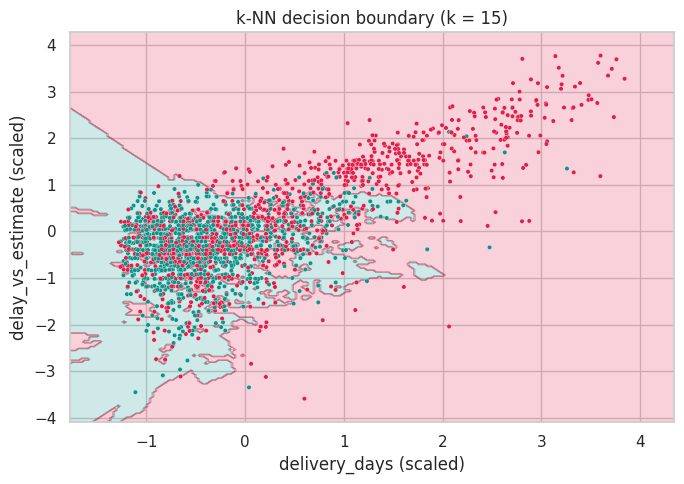

In [ ]:
# Visualize the decision boundary for a chosen k (the k knob = bias/variance)
from matplotlib.colors import ListedColormap
knn = KNeighborsClassifier(n_neighbors=15).fit(X2_tr_s, y2_tr)

xx, yy = np.meshgrid(np.linspace(X2_tr_s[:, 0].min()-0.5, X2_tr_s[:, 0].max()+0.5, 200),
                     np.linspace(X2_tr_s[:, 1].min()-0.5, X2_tr_s[:, 1].max()+0.5, 200))
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.2, cmap=ListedColormap(["#0d9488", "#e11d48"]))
plt.scatter(X2_tr_s[:, 0], X2_tr_s[:, 1], c=y2_tr, cmap=ListedColormap(["#0d9488", "#e11d48"]),
            s=10, edgecolor="white", linewidth=0.2)
plt.xlabel("delivery_days (scaled)"); plt.ylabel("delay_vs_estimate (scaled)")
plt.title("k-NN decision boundary (k = 15)")
plt.tight_layout(); plt.show()

Small `k` chases every point (high variance); large `k` smooths the boundary (higher bias). The right `k` is chosen by cross-validation, which we formalize in Session 17.

---
## 3. Linear Regression · predict shipping cost from package size

Now a regression target. Shipping cost is physically driven by how heavy and bulky a package is, so `freight_total` should be predictable from `weight_total` and `volume_total`.

In [ ]:
reg_features = ["weight_total", "volume_total"]
Xr = df[reg_features].values
yr = df["freight_total"].values
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(Xr, yr, test_size=0.25, random_state=42)

lin = LinearRegression().fit(Xr_tr, yr_tr)
pred = lin.predict(Xr_te)
print("Coefficients:", dict(zip(reg_features, np.round(lin.coef_, 5))))
print("Intercept: {:.2f}".format(lin.intercept_))
print("R2   = {:.3f}".format(r2_score(yr_te, pred)))
print("MAE  = {:.2f} BRL".format(mean_absolute_error(yr_te, pred)))
print("RMSE = {:.2f} BRL".format(np.sqrt(mean_squared_error(yr_te, pred))))

Coefficients: {'weight_total': np.float64(0.00164), 'volume_total': np.float64(0.00022)}
Intercept: 15.12
R2   = 0.396
MAE  = 8.56 BRL
RMSE = 14.81 BRL


In [ ]:
# Closed-form Normal Equation reproduces sklearn's coefficients exactly
Xb = np.c_[np.ones(len(Xr_tr)), Xr_tr]              # add bias column
beta = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ yr_tr
print("Normal Equation  -> intercept {:.4f}, coefs {}".format(beta[0], np.round(beta[1:], 5)))
print("sklearn          -> intercept {:.4f}, coefs {}".format(lin.intercept_, np.round(lin.coef_, 5)))

Normal Equation  -> intercept 15.1187, coefs [0.00164 0.00022]
sklearn          -> intercept 15.1187, coefs [0.00164 0.00022]


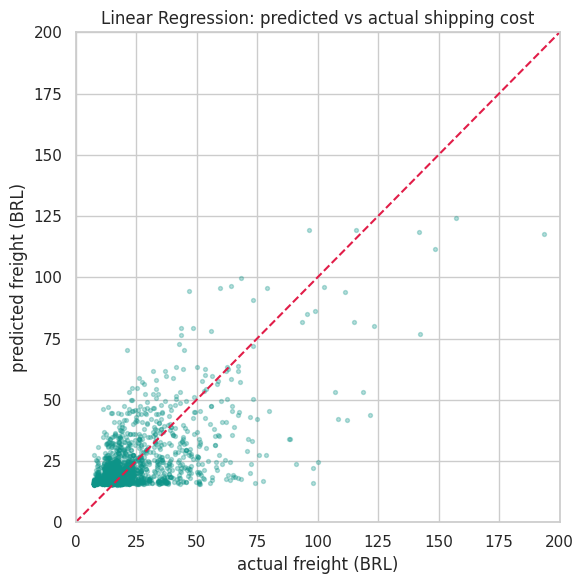

In [ ]:
# Predicted vs actual on a sample
idx = np.random.choice(len(yr_te), 2000, replace=False)
plt.figure(figsize=(6, 6))
plt.scatter(yr_te[idx], pred[idx], s=8, alpha=0.3, color="#0d9488")
lims = [0, 200]
plt.plot(lims, lims, "--", color="#e11d48", linewidth=1.5)
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("actual freight (BRL)"); plt.ylabel("predicted freight (BRL)")
plt.title("Linear Regression: predicted vs actual shipping cost")
plt.tight_layout(); plt.show()

The positive weight coefficient is interpretable: heavier orders cost more to ship. An R-squared around 0.4 means package size explains a real but partial slice of shipping cost; distance (not in our features) explains much of the rest.

---
## 4. Logistic Regression · predict a negative review

Back to classification, now with a probabilistic linear model. Logistic regression passes a linear score through the sigmoid to output a probability.

In [ ]:
scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

logreg = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train_s, y_train)
y_pred = logreg.predict(X_test_s)

print("Coefficients (standardized features):")
for name, c in sorted(zip(clf_features, logreg.coef_[0]), key=lambda t: -abs(t[1])):
    print(f"  {name:<20} {c:+.3f}")

Coefficients (standardized features):
  delivery_days        +0.564
  n_items              +0.449
  delay_vs_estimate    +0.244
  freight_total        -0.080
  weight_total         +0.058
  price_total          +0.052


The largest positive weights belong to the delivery features: long, late deliveries push the probability of a negative review up. The model rediscovered our intuition on its own.

In [ ]:
# The accuracy trap, previewed here and formalized in Session 17
baseline_acc = 1 - y_test.mean()                 # 'always predict positive'
model_acc = accuracy_score(y_test, y_pred)
print("Baseline 'always positive' accuracy: {:.3f}".format(baseline_acc))
print("Logistic regression accuracy:        {:.3f}".format(model_acc))
print("Precision: {:.3f}".format(precision_score(y_test, y_pred)))
print("Recall:    {:.3f}".format(recall_score(y_test, y_pred)))
print("F1:        {:.3f}".format(f1_score(y_test, y_pred)))

Baseline 'always positive' accuracy: 0.874
Logistic regression accuracy:        0.751
Precision: 0.275
Recall:    0.594
F1:        0.376


With `class_weight="balanced"` the model trades some accuracy to actually *catch* unhappy customers (higher recall). A model that just predicted "positive" for everyone would score high on accuracy yet be useless. That tension is the whole subject of Session 17.

---
## 5. Regularization · shrinking coefficients to fight overfitting

Regularization adds a penalty on coefficient size. Two practical points first:

1. **Regularization requires scaling.** The penalty acts on coefficient magnitude, so features must be on a comparable scale or the penalty hits them unequally. We standardize.
2. To see L1 *select* features, we add a deliberately **irrelevant random feature**. A good method should ignore it.

In [ ]:
# Standardized regression data, plus one irrelevant random feature
np.random.seed(42)
reg_feats_plus = ["weight_total", "volume_total", "random_noise"]
Xr_aug = df[["weight_total", "volume_total"]].copy()
Xr_aug["random_noise"] = np.random.randn(len(df))
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(Xr_aug.values, yr, test_size=0.25, random_state=42)
sc_reg = StandardScaler().fit(Xa_tr)
Xa_tr_s, Xa_te_s = sc_reg.transform(Xa_tr), sc_reg.transform(Xa_te)

# Ridge (L2): coefficients shrink smoothly toward zero as alpha grows
alphas = [0, 1e3, 1e4, 1e5, 1e6]
rows = []
for a in alphas:
    model = LinearRegression() if a == 0 else Ridge(alpha=a)
    model.fit(Xa_tr_s, ya_tr)
    rows.append([a, *np.round(model.coef_, 3), round(r2_score(ya_te, model.predict(Xa_te_s)), 3)])
ridge_tbl = pd.DataFrame(rows, columns=["alpha (L2)", "weight", "volume", "noise", "test_R2"])
print(ridge_tbl.to_string(index=False))

 alpha (L2)  weight  volume  noise  test_R2
        0.0   6.911   5.838  0.073    0.396
     1000.0   6.827   5.824  0.072    0.396
    10000.0   6.228   5.601  0.062    0.396
   100000.0   3.652   3.519  0.023    0.328
  1000000.0   0.734   0.719  0.002    0.088


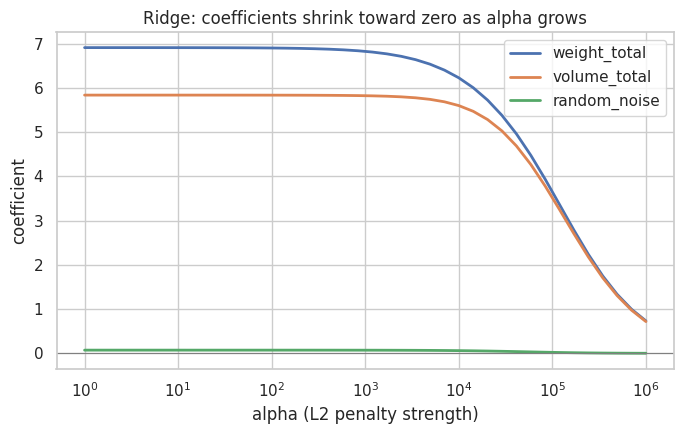

In [ ]:
# Coefficient shrinkage path (Ridge)
alpha_grid = np.logspace(0, 6, 40)
paths = np.array([Ridge(alpha=a).fit(Xa_tr_s, ya_tr).coef_ for a in alpha_grid])
plt.figure(figsize=(7, 4.5))
for j, name in enumerate(reg_feats_plus):
    plt.plot(alpha_grid, paths[:, j], label=name, linewidth=2)
plt.xscale("log"); plt.axhline(0, color="gray", linewidth=0.8)
plt.xlabel("alpha (L2 penalty strength)"); plt.ylabel("coefficient")
plt.title("Ridge: coefficients shrink toward zero as alpha grows")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# L1 (Lasso) drives the irrelevant feature exactly to zero -> built-in feature selection
print("Lasso (standardized features):")
for a in [0.01, 0.1, 0.5, 1.0, 2.0]:
    las = Lasso(alpha=a, max_iter=10000).fit(Xa_tr_s, ya_tr)
    print(f"  alpha={a:<5} weight={las.coef_[0]:6.3f}  volume={las.coef_[1]:6.3f}  "
          f"noise={las.coef_[2]:6.3f}  (zeros = {int(np.sum(np.isclose(las.coef_, 0)))})")
print("\nL2 (Ridge) for contrast keeps the noise coefficient small but non-zero:")
r = Ridge(alpha=1e4).fit(Xa_tr_s, ya_tr)
print(f"  Ridge noise coef = {r.coef_[2]:.4f}")

Lasso (standardized features):
  alpha=0.01  weight= 6.907  volume= 5.831  noise= 0.063  (zeros = 0)
  alpha=0.1   weight= 6.857  volume= 5.781  noise= 0.000  (zeros = 1)
  alpha=0.5   weight= 6.636  volume= 5.559  noise= 0.000  (zeros = 1)
  alpha=1.0   weight= 6.358  volume= 5.282  noise= 0.000  (zeros = 1)
  alpha=2.0   weight= 5.803  volume= 4.727  noise= 0.000  (zeros = 1)

L2 (Ridge) for contrast keeps the noise coefficient small but non-zero:
  Ridge noise coef = 0.0620


As the L2 penalty grows, all coefficients shrink smoothly toward zero (Ridge) without reaching it. L1 (Lasso) drives the irrelevant `random_noise` feature to **exactly zero** while keeping the real ones, a built-in form of feature selection. Note that both required standardized features to work.

---
## Wrap-up

On real Olist data we covered the four foundations:

- **k-NN** classifies by nearest neighbors; `k` balances bias and variance.
- **Linear Regression** predicts shipping cost from package size, with interpretable coefficients matching the Normal Equation.
- **Logistic Regression** predicts negative reviews and recovers the delivery-driven story on its own.
- **Regularization** shrinks coefficients (Ridge) or zeros them (Lasso) to keep models simple.

Next session: how to *evaluate* these models properly, and the tree-based models that often beat them.